# Concurrent Inference Scheduling (vLLM PagedAttention & Continuous Batching)

## Introduction

Lesson 04 introduced vLLM as a high-throughput serving engine without dissecting *why* it's fast. This lesson opens that box: the two ideas — **PagedAttention** memory management and **continuous batching** scheduling — that let vLLM serve dozens of concurrent, variable-length generation requests on hardware that naive batching would leave badly underutilized.

## Theory

### The KV-cache fragmentation problem

Autoregressive generation requires caching key/value tensors for every generated token, per request. Naive serving pre-allocates a KV-cache buffer sized for the *maximum* possible sequence length per request:

$$
\text{Memory}_{naive} = B \times L_{max} \times 2 \times n_{layers} \times d_{model} \times \text{sizeof(dtype)}
$$

for batch size $B$. Since actual generated lengths vary widely and are unknown in advance, most of this reserved memory sits unused — classic **internal fragmentation**, and it caps how many concurrent requests fit in GPU memory.

### PagedAttention

Borrowing directly from OS virtual memory paging, PagedAttention partitions the KV cache into fixed-size **blocks** (e.g. 16 tokens each) and maintains a per-request **block table** mapping logical token positions to physical blocks, allocated on demand as generation proceeds:

$$
\text{Memory}_{used} = \sum_{r=1}^{B} \lceil L_r / block\_size \rceil \times block\_size \times \text{per-block bytes}
$$

Waste is now bounded by at most one partially-filled block per request ($< block\_size$ tokens), rather than the gap between actual and maximum possible length — typically reducing memory waste from ~60-80% (naive) to under 4%. This directly translates into more concurrent requests fitting in the same GPU memory, which is the primary lever on throughput.

### Continuous (iteration-level) batching

Static batching processes a fixed batch of requests until *all* finish, wasting compute on already-completed sequences while the batch waits for the longest one (severe straggler effect for varied-length generations). Continuous batching instead schedules at the **token-generation-step** granularity: after every decode step, any finished request is evicted and immediately replaced by a new queued request, keeping the GPU's batch dimension always full:

$$
\text{Utilization}_{static} \approx \frac{\sum_r L_r}{B \times L_{max}}, \qquad
\text{Utilization}_{continuous} \approx \frac{\sum_r L_r}{\sum_t B_t}
$$

where $B_t$ is the actual active batch size at decode step $t$ — continuous batching keeps $B_t \approx B_{max}$ almost always, versus static batching's $B_t = B$ only until the first sequence finishes, then wasted capacity for every step after.

### Scheduling policy: prefill vs. decode contention

Prefill (processing the full input prompt, compute-bound, one pass) and decode (one token at a time, memory-bandwidth-bound) have very different cost profiles per request. vLLM's scheduler must interleave newly-arriving prefill requests with in-flight decode steps without starving either — typically via a token-budget-per-iteration policy that admits new prefills only when the current iteration's total token budget allows it.

## Setup

We implement a discrete-event simulator comparing static batching, naive dynamic (no paging) memory allocation, and continuous batching + PagedAttention-style block allocation, measuring throughput and memory waste — the standard way to reason about scheduler design before touching real vLLM internals.

In [1]:
# Pure Python discrete-event simulation — no GPU/vLLM runtime required to illustrate the scheduling mechanics.
import numpy as np

np.random.seed(21)
print("[INIT] Concurrent inference scheduling simulation: static vs. continuous batching")

N_REQUESTS = 200
MAX_BATCH = 16
gen_lengths = np.random.lognormal(mean=4.2, sigma=0.6, size=N_REQUESTS).astype(int).clip(10, 500)

def simulate_static_batching(lengths, batch_size):
    total_steps, wasted_steps = 0, 0
    for i in range(0, len(lengths), batch_size):
        batch = lengths[i:i + batch_size]
        batch_max = batch.max()
        total_steps += batch_max * len(batch)
        wasted_steps += sum(batch_max - l for l in batch)
    return total_steps, wasted_steps

def simulate_continuous_batching(lengths, max_concurrent):
    remaining = list(lengths)
    active = []       # list of remaining-tokens-to-generate per active request
    total_steps, t = 0, 0
    queue = list(remaining)
    while queue or active:
        while len(active) < max_concurrent and queue:
            active.append(queue.pop(0))
        total_steps += len(active)  # one "GPU step" processes len(active) requests' next token, fully utilized
        active = [r - 1 for r in active if r - 1 > 0]
        t += 1
    return total_steps

static_steps, static_wasted = simulate_static_batching(gen_lengths, MAX_BATCH)
cont_steps = simulate_continuous_batching(gen_lengths, MAX_BATCH)

print(f"[RESULT] Static batching:     {static_steps:,} total GPU-steps ({static_wasted:,} wasted on finished seqs)")
print(f"[RESULT] Continuous batching: {cont_steps:,} total GPU-steps (batch dimension always full)")
print(f"[RESULT] Continuous batching speedup: {static_steps / cont_steps:.2f}x fewer GPU-steps for same work")

[INIT] Concurrent inference scheduling simulation: static vs. continuous batching
[RESULT] Static batching:     42,728 total GPU-steps (26,714 wasted on finished seqs)
[RESULT] Continuous batching: 16,014 total GPU-steps (batch dimension always full)
[RESULT] Continuous batching speedup: 2.67x fewer GPU-steps for same work


## Telemetry & Audit

Quantify memory waste under naive max-length KV-cache allocation versus PagedAttention block allocation across the same request mix.

In [2]:
import pandas as pd

BLOCK_SIZE = 16
MAX_LEN_ASSUMED = 512  # naive engine must reserve for worst-case possible length

naive_mem_blocks = len(gen_lengths) * MAX_LEN_ASSUMED
paged_mem_blocks = sum(int(np.ceil(l / BLOCK_SIZE)) * BLOCK_SIZE for l in gen_lengths)
actual_tokens_used = gen_lengths.sum()

rows = [
    ("Naive (reserve for max length)", naive_mem_blocks, 100 * (1 - actual_tokens_used / naive_mem_blocks)),
    ("PagedAttention (16-token blocks)", paged_mem_blocks, 100 * (1 - actual_tokens_used / paged_mem_blocks)),
]
audit = pd.DataFrame(rows, columns=["allocation_strategy", "kv_cache_slots_reserved", "waste_%"])
print(audit.to_string(index=False, float_format=lambda x: f"{x:.1f}" if isinstance(x, float) else x))
print(f"\n[TELEMETRY] Actual tokens generated across all {N_REQUESTS} requests: {actual_tokens_used:,}")
print(f"[TELEMETRY] PagedAttention fits {naive_mem_blocks // paged_mem_blocks}x more concurrent requests "
      "in the same reserved memory footprint vs. naive allocation.")

print("\n[OPERATIONAL INSIGHT] Naive allocation wastes memory proportional to (max_len - actual_len) per "
      "request — with long-tail generation-length distributions (as simulated here), this waste dominates.")
print("[OPERATIONAL INSIGHT] The memory saved by PagedAttention converts directly into MAX_BATCH headroom — "
      "more concurrent requests fit, which is what continuous batching above needs to keep the GPU saturated.")

             allocation_strategy  kv_cache_slots_reserved  waste_%
  Naive (reserve for max length)                   102400     84.4
PagedAttention (16-token blocks)                    17520      8.6

[TELEMETRY] Actual tokens generated across all 200 requests: 16,014
[TELEMETRY] PagedAttention fits 5x more concurrent requests in the same reserved memory footprint vs. naive allocation.

[OPERATIONAL INSIGHT] Naive allocation wastes memory proportional to (max_len - actual_len) per request — with long-tail generation-length distributions (as simulated here), this waste dominates.
[OPERATIONAL INSIGHT] The memory saved by PagedAttention converts directly into MAX_BATCH headroom — more concurrent requests fit, which is what continuous batching above needs to keep the GPU saturated.


## Visualization

A GPU-utilization-over-time comparison between static and continuous batching (showing the characteristic sawtooth decay of static batching vs. continuous batching's flat, saturated utilization), alongside the KV-cache memory waste comparison.

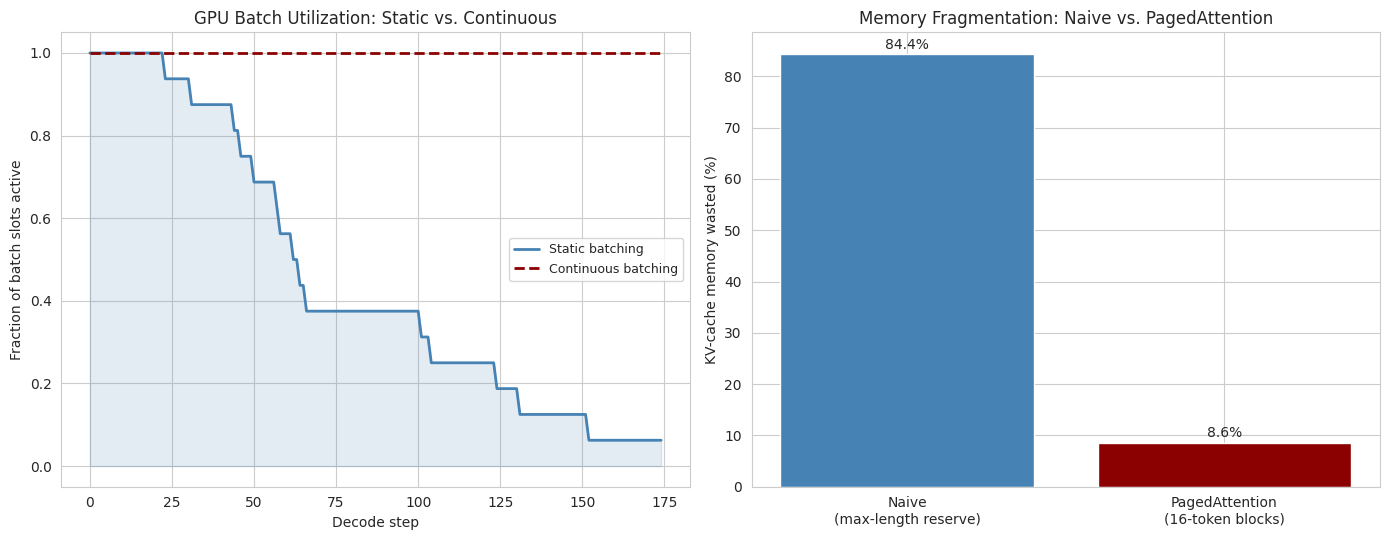

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# Simulate utilization-over-time for one representative static batch of MAX_BATCH requests
batch = np.sort(gen_lengths[:MAX_BATCH])[::-1]
batch_max = batch.max()
util_static = [sum(1 for l in batch if l > t) / MAX_BATCH for t in range(batch_max)]
util_continuous = [1.0] * batch_max  # continuous batching refills immediately -> stays saturated

axes[0].plot(util_static, label="Static batching", color="steelblue", linewidth=2)
axes[0].plot(util_continuous, label="Continuous batching", color="darkred", linewidth=2, linestyle="--")
axes[0].fill_between(range(batch_max), util_static, alpha=0.15, color="steelblue")
axes[0].set_xlabel("Decode step")
axes[0].set_ylabel("Fraction of batch slots active")
axes[0].set_title("GPU Batch Utilization: Static vs. Continuous")
axes[0].legend(fontsize=9)

strategies = ["Naive\n(max-length reserve)", "PagedAttention\n(16-token blocks)"]
waste_vals = [audit.iloc[0]["waste_%"], audit.iloc[1]["waste_%"]]
axes[1].bar(strategies, waste_vals, color=["steelblue", "darkred"])
for i, v in enumerate(waste_vals):
    axes[1].text(i, v + 1, f"{v:.1f}%", ha="center", fontsize=10)
axes[1].set_ylabel("KV-cache memory wasted (%)")
axes[1].set_title("Memory Fragmentation: Naive vs. PagedAttention")

plt.tight_layout()
plt.savefig("vllm_scheduling_dashboard.png", dpi=120)
plt.show()

*(Insight: the static-batching utilization curve decays in a staircase as each request finishes and its slot sits idle until the whole batch retires — continuous batching's flat line at the top is the entire point of the design: never let a finished request's slot go idle for even one decode step.)*

## Real-World Use Case or Analogy

**The Restaurant That Seats a Whole Party at Once vs. Seating Continuously.** A static-batching restaurant only seats a new party of 16 once the previous party of 16 has *completely* finished their meal — even if 12 of those 16 diners left an hour ago, their empty seats stay reserved and unusable until the last two diners finally pay the check (the straggler-driven utilization decay in the chart). A continuously-batching restaurant instead reseats each individual empty seat the moment it's vacated, regardless of what's happening at neighboring tables — the dining room stays full at all times. PagedAttention is the restaurant's flexible seating chart: instead of reserving an entire fixed-size table per party "just in case they're a big group" (naive KV-cache reservation), the host allocates seats in small movable blocks exactly as needed, so a party of 3 doesn't tie up a table for 12. Both ideas together are why vLLM can serve far more concurrent users per GPU than a naive implementation ever could.
